In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

D:\installana\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


In [2]:
dataset = pd.read_csv('/Users/Windows 10 Pro/Desktop/Churn_Modelling.csv')
dataset

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,9999,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


In [3]:
dataset.drop('RowNumber', axis=1, inplace = True)
dataset.drop('CustomerId', axis=1, inplace = True)
dataset.drop('Surname', axis=1, inplace = True)

dataset

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...
9995,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


In [4]:
dataset.describe()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [5]:
print(dataset['Geography'].unique())

['France' 'Spain' 'Germany']


In [6]:
print(dataset['Gender'].unique())

['Female' 'Male']


In [7]:
# Process categorical variables
dataset_orig = dataset.copy()
dataset = pd.get_dummies(dataset, drop_first = True)

dataset

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,1,False,False,False
1,608,41,1,83807.86,1,0,1,112542.58,0,False,True,False
2,502,42,8,159660.80,3,1,0,113931.57,1,False,False,False
3,699,39,1,0.00,2,0,0,93826.63,0,False,False,False
4,850,43,2,125510.82,1,1,1,79084.10,0,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,771,39,5,0.00,2,1,0,96270.64,0,False,False,True
9996,516,35,10,57369.61,1,1,1,101699.77,0,False,False,True
9997,709,36,7,0.00,1,0,1,42085.58,1,False,False,False
9998,772,42,3,75075.31,2,1,0,92888.52,1,True,False,True


In [8]:
# Generate independent variables and dependent variables
X = np.append(dataset.iloc[:, :8].values, dataset.iloc[:, 9:].values, axis = 1)
y = dataset.iloc[:, 8].values

In [9]:
# Split the dataset into training, validation, and test sets

from sklearn.model_selection import train_test_split

# First split: 80% training, 20% temporary data
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.20,
    random_state=0,
    stratify=y
)

# Second split: 10% validation, 10% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=0,
    stratify=y_temp
)

print("Training set:", X_train.shape)
print("Validation set:", X_val.shape)
print("Test set:", X_test.shape)

Training set: (8000, 11)
Validation set: (1000, 11)
Test set: (1000, 11)


In [10]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()

# Fit the scaler only on the training data
X_train = sc.fit_transform(X_train)

# Transform validation and test data using the same scaler
X_val = sc.transform(X_val)
X_test = sc.transform(X_test)

In [11]:
X_train

array([[-1.24021723,  0.77986083,  0.35390313, ..., -0.57812007,
        -0.57504086, -1.09665089],
       [ 0.75974873, -0.27382717,  0.35390313, ...,  1.72974448,
        -0.57504086,  0.91186722],
       [-1.72725557, -0.9443559 , -0.3390904 , ..., -0.57812007,
        -0.57504086, -1.09665089],
       ...,
       [-0.51484098,  0.87565065,  1.39339343, ...,  1.72974448,
        -0.57504086,  0.91186722],
       [ 0.73902369, -0.36961699, -1.03208393, ..., -0.57812007,
        -0.57504086, -1.09665089],
       [ 0.95663657, -1.32751517,  0.35390313, ..., -0.57812007,
         1.73900686,  0.91186722]])

In [12]:
# check the shape of X_train
X_train.shape

(8000, 11)

In [13]:
import random
seed = 2021
random.seed(seed)
np.random.seed(seed)
tf.random.set_seed(seed)

In [14]:
from keras.models import Sequential
from keras.layers import Dense, Input  # ← Ajoute Input ici

def create_model(input_dim, hiden_layer_nums, units_list):
    model = Sequential()
    
    # Ajoute cette ligne AVANT la boucle
    model.add(Input(shape=(input_dim,)))
    
    for i in range(hiden_layer_nums):
        # Plus besoin de input_dim ici
        model.add(Dense(units_list[i], activation='relu'))
    
    model.add(Dense(1, activation='sigmoid'))
    return model


In [15]:
# Set hyperparameters
BATCH_SIZE = 10
EPOCHS = 100

In [16]:
#set three models
HIDDEN_LAYER_NUM_LIST = [1, 2, 3]    # List of model layer numbers
HIDDEN_LAYER_NEURON_LIST = [[8], [32, 16], [128, 64, 32]]    # List of the number of neurons in the hidden layers of the model

In [17]:
from keras import optimizers

historys_arch = []  # Store the loss and accuracy data during training

for idx, num in enumerate(HIDDEN_LAYER_NUM_LIST):

    print('[INFO] The current network structure includes {} layers of hidden layer'.format(num))

    model = create_model(
        X_train.shape[1],
        num,
        HIDDEN_LAYER_NEURON_LIST[idx]
    )

    # Compile the model
    opt = optimizers.SGD(learning_rate=0.001)

    model.compile(
        optimizer=opt,
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    history = model.fit(
        X_train,
        y_train,
        validation_data=(X_val, y_val),
        batch_size=BATCH_SIZE,
        epochs=EPOCHS,
        verbose=1
    )

    # Store the training history
    historys_arch.append(history)

[INFO] The current network structure includes 1 layers of hidden layer
Epoch 1/100
800/800 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7571 - loss: 0.6237 - val_accuracy: 0.7750 - val_loss: 0.6171
Epoch 2/100
800/800 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7815 - loss: 0.5926 - val_accuracy: 0.7880 - val_loss: 0.5894
Epoch 3/100
800/800 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7889 - loss: 0.5696 - val_accuracy: 0.7930 - val_loss: 0.5677
Epoch 4/100
800/800 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7915 - loss: 0.5514 - val_accuracy: 0.7960 - val_loss: 0.5501
Epoch 5/100
800/800 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7934 - loss: 0.5366 - val_accuracy: 0.7980 - val_loss: 0.5353
Epoch 6/100
800/800 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7944 - loss: 0.5242 - val_accuracy: 0.7980 - val_loss: 0.5230
Epoch 7/100
800/800 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7951 - loss: 0.5138 - val_accuracy: 0.7990 - val_loss: 0.5126
Epoch 8/100
800/800 ━━━━━━

In [18]:
print(len(historys_arch))

for idx, history in enumerate(historys_arch):
    print(f"Model {idx} :", history.history.keys())

3
Model 0 : dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])
Model 1 : dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])
Model 2 : dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


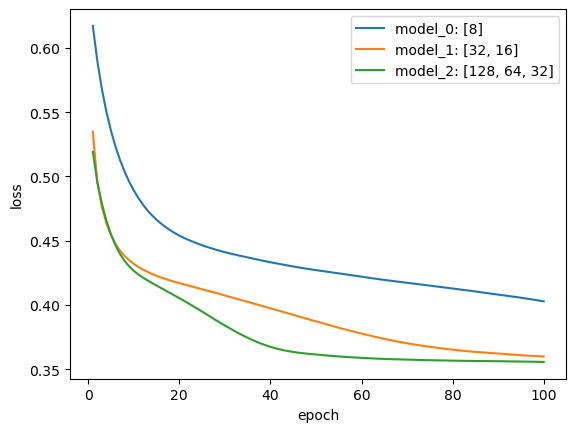

In [19]:
plt.figure()
legends = []
x = np.arange(1,EPOCHS + 1)
for idx,history in enumerate(historys_arch):
    plt.plot(x ,history.history['val_loss']) # Plot the val_loss curve
    legends.append('model_{}: {}'.format(idx, HIDDEN_LAYER_NEURON_LIST[idx]))
plt.ylabel('loss')                   # Set the ordinate
plt.xlabel('epoch')                  # Set the abscissa
plt.legend(legends)                  # add labels
plt.show()

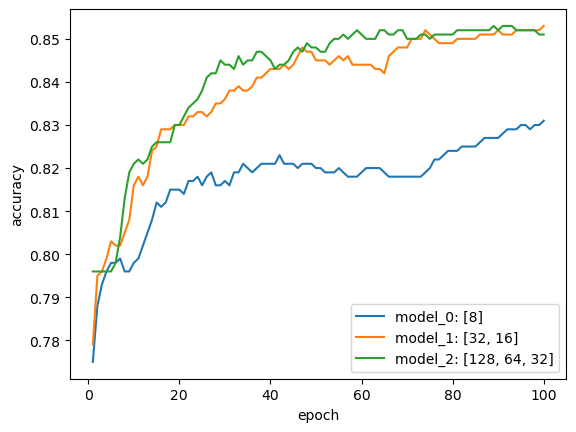

In [20]:
plt.figure()
legends = []
x = np.arange(1,EPOCHS + 1)
for idx,history in enumerate(historys_arch):
    plt.plot(x, history.history['val_accuracy']) 
    legends.append('model_{}: {}'.format(idx, HIDDEN_LAYER_NEURON_LIST[idx]))
plt.ylabel('accuracy')                   # set the ordinate
plt.xlabel('epoch')                  # Set the abscissa
plt.legend(legends)                  # add labels
plt.show()

In [21]:
LR = [0.01, 0.005, 0.001] # try three different learning rates

In [22]:
historys_lr = []  # Store the loss and accuracy data during training

for idx, lr in enumerate(LR):

    print('[INFO] LR:{}'.format(lr))

    # Fix the model structure
    model = create_model(
        X_train.shape[1],
        3,
        [128, 64, 32]
    )

    # Create SGD optimizer with the current learning rate
    opt = optimizers.SGD(learning_rate=lr)

    # Compile the model
    model.compile(
        loss='binary_crossentropy',
        optimizer=opt,
        metrics=['accuracy']
    )

    # Train with validation set
    history = model.fit(
        X_train,
        y_train,
        validation_data=(X_val, y_val),
        batch_size=BATCH_SIZE,
        epochs=EPOCHS,
        verbose=1
    )

    # Store the training history
    historys_lr.append(history.history)

[INFO] LR:0.01
Epoch 1/100
800/800 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8009 - loss: 0.4591 - val_accuracy: 0.8240 - val_loss: 0.4171
Epoch 2/100
800/800 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8234 - loss: 0.4074 - val_accuracy: 0.8350 - val_loss: 0.3954
Epoch 3/100
800/800 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8426 - loss: 0.3813 - val_accuracy: 0.8430 - val_loss: 0.3746
Epoch 4/100
800/800 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8553 - loss: 0.3597 - val_accuracy: 0.8470 - val_loss: 0.3625
Epoch 5/100
800/800 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8604 - loss: 0.3476 - val_accuracy: 0.8460 - val_loss: 0.3588
Epoch 6/100
800/800 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8620 - loss: 0.3413 - val_accuracy: 0.8510 - val_loss: 0.3580
Epoch 7/100
800/800 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8624 - loss: 0.3372 - val_accuracy: 0.8560 - val_loss: 0.3579
Epoch 8/100
800/800 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8631 - loss: 0.

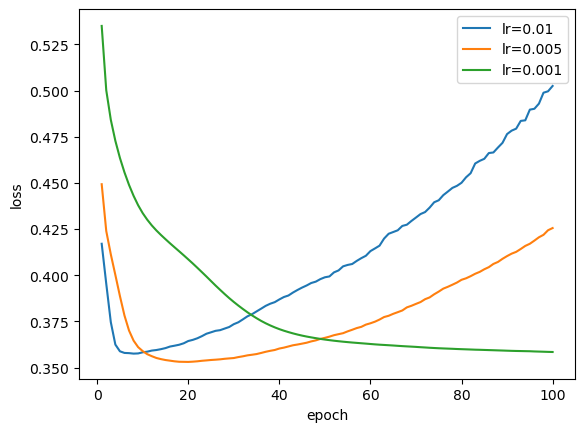

In [23]:
plt.figure()
legends = []
x = np.arange(1,EPOCHS + 1)
for idx, history in enumerate(historys_lr):
    plt.plot(x, history['val_loss']) # Plot the val_loss curve
    legends.append('lr={}'.format(LR[idx]))
plt.ylabel('loss') # set the ordinate
plt.xlabel('epoch') 
plt.legend(legends) # add labels
plt.show()

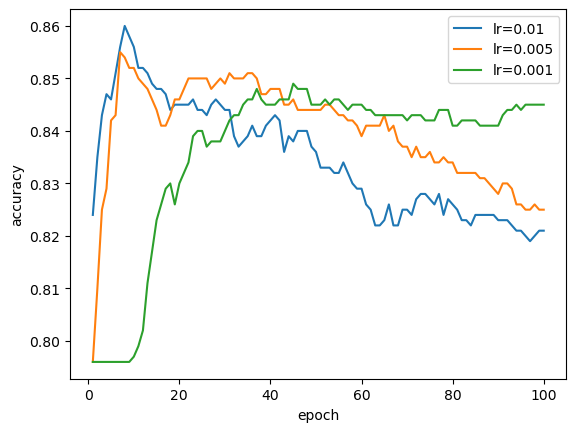

In [24]:
plt.figure()
legends = []
x = np.arange(1,EPOCHS + 1)
for idx, history in enumerate(historys_lr):
    plt.plot(x, history['val_accuracy']) # plot the val_accuracy curve
    legends.append('lr={}'.format(LR[idx]))
plt.ylabel('accuracy') # set the ordinate
plt.xlabel('epoch') 
plt.legend(legends) # add the labels
plt.show()

In [25]:
from keras.optimizers import SGD, RMSprop, Adam, Nadam
LR = 0.001    # Fix the learning rate of the model
optimizer_dict = {'SGD': SGD(learning_rate = LR),
                 'RMSprop': RMSprop(learning_rate = LR),
                 'Adam': Adam(learning_rate = LR),
                 'Nadam': Nadam(learning_rate = LR)}

In [26]:
historys_opt = {}    # Store the loss and accuracy data
for key, opt in optimizer_dict.items():
    print('[INFO] optimizer:{}'.format(key))
    # Fix the model structure
    model = create_model(
        X_train.shape[1],
        3,
        [128, 64, 32]
    )
    # Compile the model
    model.compile(
        loss='binary_crossentropy',
        optimizer=opt,
        metrics=['accuracy']
    )
    # Train with validation set
    history = model.fit(
        X_train,
        y_train,
        validation_data=(X_val, y_val),
        batch_size=BATCH_SIZE,
        epochs=EPOCHS,
        verbose=1
    )
    # Store the training history for this optimizer
    historys_opt[key] = history.history

[INFO] optimizer:SGD
Epoch 1/100
800/800 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7818 - loss: 0.5800 - val_accuracy: 0.7960 - val_loss: 0.5272
Epoch 2/100
800/800 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7962 - loss: 0.5085 - val_accuracy: 0.7960 - val_loss: 0.4937
Epoch 3/100
800/800 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7962 - loss: 0.4880 - val_accuracy: 0.7960 - val_loss: 0.4784
Epoch 4/100
800/800 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7962 - loss: 0.4761 - val_accuracy: 0.7960 - val_loss: 0.4671
Epoch 5/100
800/800 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7962 - loss: 0.4663 - val_accuracy: 0.7960 - val_loss: 0.4575
Epoch 6/100
800/800 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7962 - loss: 0.4576 - val_accuracy: 0.7960 - val_loss: 0.4493
Epoch 7/100
800/800 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7962 - loss: 0.4500 - val_accuracy: 0.7960 - val_loss: 0.4423
Epoch 8/100
800/800 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7972 - lo

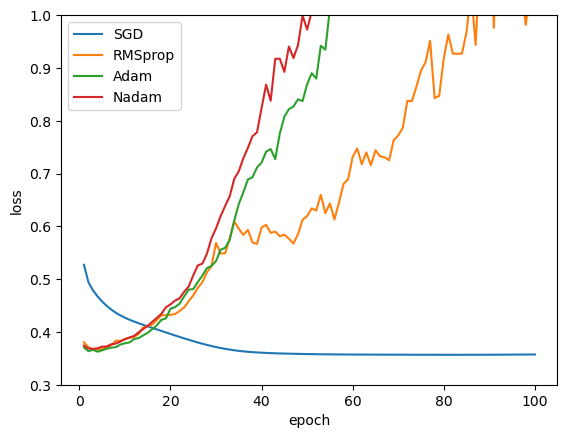

In [27]:
plt.figure()
legends = []
x = np.arange(1,EPOCHS + 1)
for key, history in historys_opt.items():
    plt.plot(x ,history['val_loss']) # plot the val_loss curve
    legends.append(key)
       
plt.ylabel('loss') # set the ordinate
plt.ylim([0.3,1.0])
plt.xlabel('epoch') 
plt.legend(legends) 
plt.show()

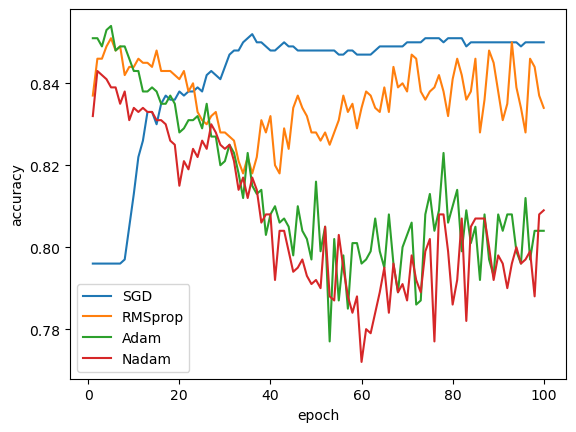

In [28]:
plt.figure()
legends = []
x = np.arange(1,EPOCHS + 1)
for key, history in historys_opt.items():
    plt.plot(x ,history['val_accuracy']) 
    legends.append(key)
       
plt.ylabel('accuracy') 
plt.xlabel('epoch') 
plt.legend(legends) 
plt.show()

In [29]:
# Create the final model with the optimal architecture
model = create_model(
    X_train.shape[1],
    3,
    [128, 64, 32]
)
# Compile the final model with the optimal learning rate and optimizer
model.compile(
    loss='binary_crossentropy',
    optimizer=optimizers.SGD(learning_rate=0.001),
    metrics=['accuracy']
)
# Train the final model using the training and validation sets
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    verbose=1
)

Epoch 1/100
800/800 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6671 - loss: 0.6325 - val_accuracy: 0.7960 - val_loss: 0.5491
Epoch 2/100
800/800 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7962 - loss: 0.5201 - val_accuracy: 0.7960 - val_loss: 0.5008
Epoch 3/100
800/800 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7962 - loss: 0.4914 - val_accuracy: 0.7960 - val_loss: 0.4814
Epoch 4/100
800/800 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7962 - loss: 0.4764 - val_accuracy: 0.7960 - val_loss: 0.4671
Epoch 5/100
800/800 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7959 - loss: 0.4642 - val_accuracy: 0.7960 - val_loss: 0.4552
Epoch 6/100
800/800 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7975 - loss: 0.4535 - val_accuracy: 0.8040 - val_loss: 0.4452
Epoch 7/100
800/800 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8025 - loss: 0.4443 - val_accuracy: 0.8190 - val_loss: 0.4371
Epoch 8/100
800/800 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8089 - loss: 0.4364 - val_accu

In [30]:
# Final evaluation on the test set
test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test,
    verbose=1
)
print('Test Loss: {:.4f}'.format(test_loss))
print('Test Accuracy: {:.4f}'.format(test_accuracy))

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8670 - loss: 0.3337  
Test Loss: 0.3337
Test Accuracy: 0.8670


In [31]:
# Generate predictions on the test set
y_pred_prob = model.predict(X_test)
# Convert probabilities into binary predictions
y_pred = (y_pred_prob >= 0.5).astype(int).flatten()
print('First 10 predicted probabilities:')
print(y_pred_prob[:10].flatten())
print('\nFirst 10 predicted classes:')
print(y_pred[:10])

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
First 10 predicted probabilities:
[0.09445257 0.20420136 0.0672627  0.48492798 0.11955725 0.01596927
 0.16706663 0.17988032 0.653614   0.00576905]

First 10 predicted classes:
[0 0 0 0 0 0 0 0 1 0]


Confusion Matrix:
[[773  24]
 [109  94]]


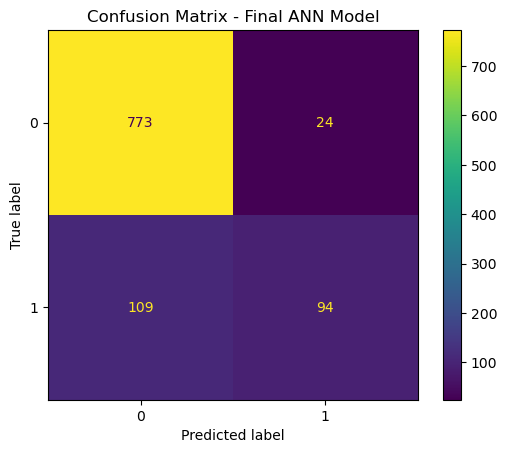

In [32]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)
# Display confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[0, 1]
)
disp.plot()
plt.title("Confusion Matrix - Final ANN Model")
plt.show()

In [33]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)
# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_prob)
print("Final Model Performance")
print("-----------------------")
print("Accuracy : {:.4f}".format(accuracy))
print("Precision: {:.4f}".format(precision))
print("Recall   : {:.4f}".format(recall))
print("F1-score : {:.4f}".format(f1))
print("ROC-AUC  : {:.4f}".format(roc_auc))

Final Model Performance
-----------------------
Accuracy : 0.8670
Precision: 0.7966
Recall   : 0.4631
F1-score : 0.5857
ROC-AUC  : 0.8661


In [34]:
# test the model using the test data
credit_score = 755
age = 38
tenure = 1
balance = 82083.5
num_of_products = 1
has_cr_card = 0
is_active_member = 1
estimated_salary = 10333.8
geography_germany = 1
geography_spain = 0
gender_male = 0

new_data = np.array([[credit_score, age, tenure, balance, num_of_products, has_cr_card,
                      is_active_member, estimated_salary, geography_germany,
                      geography_spain, gender_male]])

In [35]:
new_data_pred = model.predict(sc.transform(new_data))
print (new_data_pred)
if new_data_pred > 0.5:
    print('This client will leave us.。')
else:
    print('This client will not leave us.')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
[[0.4647741]]
This client will not leave us.
